# <center>**Tecnológico de Costa Rica**</center>

***IC-6200 / Inteligencia artificial***

Profesor

*   **Efren Jimenez Delgado**

Proyecto JarvisTEC, I Semestre 2026

## Análisis del Problema

Queremos estimar el precio promedio de un aguacate Hass en el mercado minorista de Estados Unidos a partir de tres datos que el usuario conoce: la **región**, el **tipo** (convencional u orgánico) y la **fecha**.

Es un problema de **regresión supervisada** sobre una serie de tiempo en panel: hay una serie por cada región y tipo. La variable objetivo es `AveragePrice`, en dólares por unidad.

Hay un detalle importante: el usuario puede preguntar por fechas posteriores a los datos. Por eso la evaluación tiene que medir la capacidad de **predecir el futuro** y no solo de reproducir el pasado.

# Caso Aplicado: Precio del Aguacate
## Regresión sobre una serie de tiempo con partición temporal

---

**Temas:** Series de tiempo · Partición temporal · Validación cruzada de ventana creciente · Ridge, Random Forest y Gradient Boosting  
**Herramientas:** Python · Pandas · Scikit-learn · Seaborn

---

### El hilo conductor

| Etapa | Pregunta central |
|---|---|
| 1 — Entendimiento | ¿Qué variables conoce el usuario al preguntar y cuáles no? |
| 2 — Exploración | ¿Hay estacionalidad, diferencias entre regiones y entre tipos? |
| 3 — Modelo | ¿Qué modelo predice mejor las semanas que vienen después del entrenamiento? |
| 4 — Predicción | ¿Cuánto costará un aguacate en cierta región y fecha? |

> Nota: en una serie de tiempo no se puede dividir al azar. Si se entrena con semanas posteriores a las que se evalúan, el modelo hace trampa sin querer.

Este notebook es un extra del modelo 09 del proyecto: reproduce de forma didáctica el entrenamiento que hace `train.py` y se puede probar en Google Colab. No reemplaza al código del repositorio.

### Autores

   * Equipo JarvisTEC (proyecto de la primera etapa)

### Librerías

In [1]:
# Manejo de datasets
import pandas as pd
import numpy as np
# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
# Modelos
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
# Ignorar Warnings
import warnings
warnings.filterwarnings('ignore')

SEMILLA = 42

---
# Sección 1: Entendimiento de los Datos
---

## Entendimiento de los Datos

Los datos semanales son del Hass Avocado Board (Kiggins, 2018). Hay 18 249 filas: 169 semanas, 54 regiones y 2 tipos.

- Date         : fecha de la semana (domingo)
- AveragePrice : variable objetivo, precio promedio por aguacate en dólares
- type         : variable cualitativa, `conventional` u `organic`
- region       : variable cualitativa, 54 valores (incluye agregados como `TotalUS` y `West`)
- Total Volume, 4046, 4225, 4770, Total Bags, Small Bags, Large Bags, XLarge Bags : volúmenes de venta, **no se usan**
- year, columna sin nombre : índice y año, se descartan (el año sale de la fecha)

El usuario no conoce los volúmenes de venta cuando consulta, y se registran en la misma semana que el precio. Un modelo que los use no se puede ejecutar en la aplicación, así que se excluyen.

Los datos están en el archivo `dataset.csv` de la carpeta `backend/features/modelo_09_aguacate/` del repositorio. Son 18 249 filas y 14 columnas.

En Colab hay dos formas de usarlo: arrastrarlo al panel de archivos (queda en `sample_data/`) o subirlo cuando la celda lo pida.

In [2]:
# Ubicar el archivo de datos (Colab o ejecución local)
import os

RUTA = next((r for r in ("sample_data/dataset.csv", "dataset.csv") if os.path.exists(r)), None)
if RUTA is None:
    try:
        from google.colab import files
        print("Seleccione el archivo dataset.csv")
        RUTA = next(iter(files.upload()))
    except ImportError:
        raise FileNotFoundError("No se encontró dataset.csv: colóquelo en sample_data/ o en la carpeta actual")
print("Archivo de datos:", RUTA)

Archivo de datos: sample_data/dataset.csv


In [3]:
# Cargar los datos
datos = pd.read_csv(RUTA, parse_dates=["Date"])
datos.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [4]:
# Información del dataset
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Unnamed: 0    18249 non-null  int64         
 1   Date          18249 non-null  datetime64[us]
 2   AveragePrice  18249 non-null  float64       
 3   Total Volume  18249 non-null  float64       
 4   4046          18249 non-null  float64       
 5   4225          18249 non-null  float64       
 6   4770          18249 non-null  float64       
 7   Total Bags    18249 non-null  float64       
 8   Small Bags    18249 non-null  float64       
 9   Large Bags    18249 non-null  float64       
 10  XLarge Bags   18249 non-null  float64       
 11  type          18249 non-null  str           
 12  year          18249 non-null  int64         
 13  region        18249 non-null  str           
dtypes: datetime64[us](1), float64(9), int64(2), str(2)
memory usage: 1.9 MB


In [5]:
df = datos.rename(columns={"Date": "fecha", "AveragePrice": "precio", "type": "tipo"})[["fecha", "region", "tipo", "precio"]]
df = df.sort_values(["fecha", "region", "tipo"]).reset_index(drop=True)

print("Filas:", len(df), " Semanas:", df.fecha.nunique(), " Regiones:", df.region.nunique())
print("Rango:", df.fecha.min().date(), "a", df.fecha.max().date())
print("Nulos:", int(df.isna().sum().sum()), " Duplicados (fecha, región, tipo):", int(df.duplicated(["fecha", "region", "tipo"]).sum()))
df["precio"].describe().round(2)

Filas: 18249  Semanas: 169  Regiones: 54
Rango: 2015-01-04 a 2018-03-25
Nulos: 0  Duplicados (fecha, región, tipo): 0


count    18249.00
mean         1.41
std          0.40
min          0.44
25%          1.10
50%          1.37
75%          1.66
max          3.25
Name: precio, dtype: float64

---
# Sección 2: Exploración de los Datos
---

## Exploración de los Datos

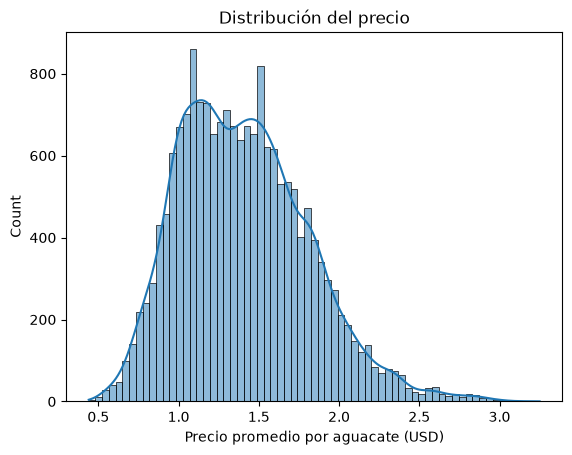

,mean,std
tipo,,
conventional,1.16,0.26
organic,1.65,0.36


In [6]:
sns.histplot(df["precio"], kde=True)
plt.xlabel("Precio promedio por aguacate (USD)")
plt.title("Distribución del precio")
plt.show()
df.groupby("tipo")["precio"].agg(["mean", "std"]).round(2)

El precio del orgánico es más alto que el del convencional, y las dos distribuciones se solapan bastante.

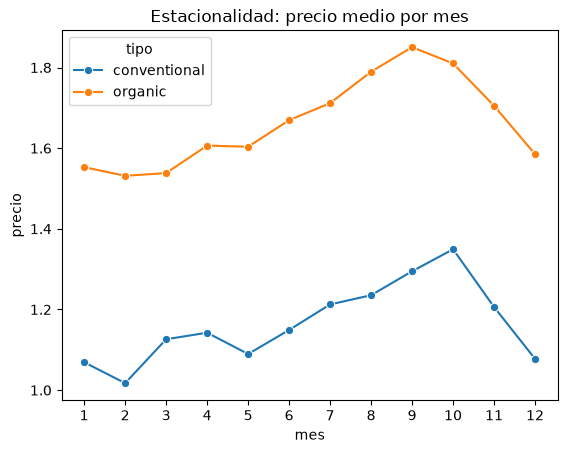

In [7]:
por_mes = df.assign(mes=df.fecha.dt.month).groupby(["mes", "tipo"])["precio"].mean().reset_index()
sns.lineplot(data=por_mes, x="mes", y="precio", hue="tipo", marker="o")
plt.title("Estacionalidad: precio medio por mes")
plt.xticks(range(1, 13))
plt.show()

Hay estacionalidad anual clara: el precio es más bajo a inicios de año y sube hacia septiembre y octubre.

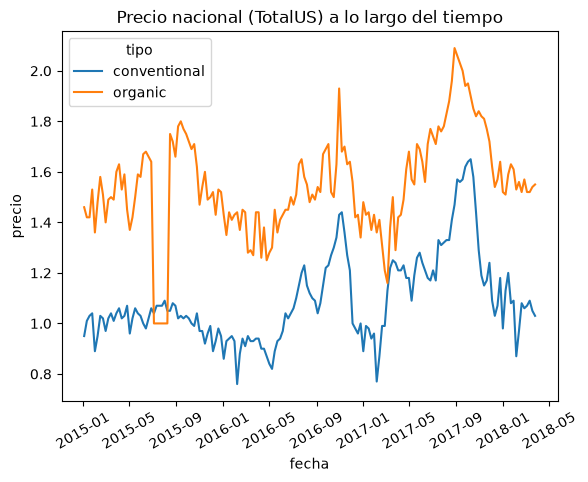

In [8]:
nacional = df[df.region == "TotalUS"]
sns.lineplot(data=nacional, x="fecha", y="precio", hue="tipo")
plt.title("Precio nacional (TotalUS) a lo largo del tiempo")
plt.xticks(rotation=30)
plt.show()

El nivel general cambia de un año a otro de forma no estacional (por ejemplo, el pico de agosto a octubre de 2017). Eso es algo que la región, el tipo y la fecha no pueden anticipar.

In [9]:
medias = df.groupby("region")["precio"].mean().sort_values()
pd.concat([medias.head(5), medias.tail(5)]).round(2)

region
Houston                1.05
DallasFtWorth          1.09
SouthCentral           1.10
CincinnatiDayton       1.21
Nashville              1.21
Sacramento             1.62
Philadelphia           1.63
NewYork                1.73
SanFrancisco           1.80
HartfordSpringfield    1.82
Name: precio, dtype: float64

---
# Sección 3: Ajuste del Modelo
---

## Modelo de Machine Learning

### Partición temporal

Las últimas 34 semanas (20 % de las fechas) son la prueba y el resto es el entrenamiento. Así se mide cuánto acierta el modelo con semanas que no vio.

In [10]:
FRACCION_PRUEBA = 0.20
fechas = np.sort(df.fecha.unique())
corte = pd.Timestamp(fechas[int(len(fechas) * (1 - FRACCION_PRUEBA))])
train = df[df.fecha < corte].reset_index(drop=True)
test = df[df.fecha >= corte].reset_index(drop=True)
print("Entrenamiento:", len(train), "filas hasta", train.fecha.max().date())
print("Prueba:", len(test), "filas desde", corte.date())

Entrenamiento: 14577 filas hasta 2017-07-30
Prueba: 3672 filas desde 2017-08-06


### Transformador de fechas

El modelo recibe la fecha y la convierte en el mes, la semana del año y una tendencia `t` (años desde el inicio). Todo va dentro del `Pipeline`, así que se aplica igual al entrenar y al predecir.

Dos decisiones importantes:
- La tendencia `t` se **trunca al último valor visto en el entrenamiento**: el modelo no extrapola una tendencia a fechas futuras.
- La semana se calcula con el día del año y no con el calendario ISO, porque la semana ISO contradice al mes cerca de año nuevo y produce saltos falsos en el precio.

In [11]:
INICIO = pd.Timestamp("2015-01-04")  # primera semana del dataset

class CaracteristicasFecha(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.t_max_ = float(self._anios(pd.to_datetime(X["fecha"])).max())
        return self

    @staticmethod
    def _anios(fechas):
        return (fechas - INICIO).dt.days / 365.25

    def transform(self, X):
        fechas = pd.to_datetime(X["fecha"])
        return pd.DataFrame({
            "region": X["region"].to_numpy(),
            "tipo": X["tipo"].to_numpy(),
            "mes": fechas.dt.month.to_numpy(),
            "semana": np.minimum((fechas.dt.dayofyear - 1) // 7 + 1, 52).to_numpy(),
            "t": np.minimum(self._anios(fechas).to_numpy(), self.t_max_),
        }, index=X.index)

### Candidatos

Se comparan siete variantes, con y sin la tendencia. La **línea base** usa solo la región y el tipo, es decir, el precio medio de cada serie.

In [12]:
VARIABLES = ["region", "tipo", "fecha"]
OBJETIVO = "precio"

def armar(estimador, categoricas, numericas, escala="passthrough"):
    columnas = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categoricas),
        ("num", escala if numericas else "drop", numericas),
    ])
    return Pipeline([("fecha", CaracteristicasFecha()), ("pre", columnas), ("modelo", estimador)])

def candidatos():
    grupo = ["region", "tipo"]
    ridge = lambda: RidgeCV(alphas=np.logspace(-2, 3, 20))
    bosque = lambda: RandomForestRegressor(n_estimators=100, min_samples_leaf=10, max_depth=14, random_state=SEMILLA, n_jobs=-1)
    boosting = lambda: HistGradientBoostingRegressor(max_iter=200, learning_rate=0.05, early_stopping=False, random_state=SEMILLA)
    return {
        "efecto región y tipo (línea base)": armar(LinearRegression(), grupo, []),
        "ridge estacional": armar(ridge(), grupo + ["mes"], []),
        "ridge estacional + tendencia": armar(ridge(), grupo + ["mes"], ["t"], StandardScaler()),
        "random forest": armar(bosque(), grupo, ["mes", "semana"]),
        "random forest + tendencia": armar(bosque(), grupo, ["t", "mes", "semana"]),
        "gradient boosting": armar(boosting(), grupo, ["mes", "semana"]),
        "gradient boosting + tendencia": armar(boosting(), grupo, ["t", "mes", "semana"]),
    }

### Selección con validación cruzada de ventana creciente

La selección usa **solo el entrenamiento**. Cada pliegue entrena con semanas anteriores y evalúa 20 semanas posteriores, y todas las filas de una misma semana van juntas (Bergmeir y Benítez, 2012).

In [13]:
def cv_por_semanas(datos, n_splits=3, semanas=20):
    sem = np.sort(datos.fecha.unique())
    pliegues = []
    for entrena, prueba in TimeSeriesSplit(n_splits=n_splits, test_size=semanas).split(sem):
        pliegues.append((np.flatnonzero(datos.fecha.isin(sem[entrena])), np.flatnonzero(datos.fecha.isin(sem[prueba]))))
    return pliegues

pliegues = cv_por_semanas(train)
filas = {}
for nombre, pipe in candidatos().items():
    r = cross_validate(pipe, train[VARIABLES], train[OBJETIVO], cv=pliegues, scoring={"rmse": "neg_root_mean_squared_error", "r2": "r2"})
    filas[nombre] = {"RMSE cv": -r["test_rmse"].mean(), "desviación": r["test_rmse"].std(), "R2 cv": r["test_r2"].mean()}
comparacion = pd.DataFrame(filas).T.round(3)
comparacion

,RMSE cv,desviación,R2 cv
efecto región y tipo (línea base),0.307,0.016,0.447
ridge estacional,0.303,0.025,0.459
ridge estacional + tendencia,0.322,0.026,0.388
random forest,0.330,0.024,0.358
random forest + tendencia,0.337,0.008,0.327
gradient boosting,0.298,0.021,0.477
gradient boosting + tendencia,0.288,0.019,0.509


Las diferencias entre los tres mejores son menores que la variación entre pliegues (alrededor de 0.02), así que no se pueden distinguir con seguridad. La evidencia sobre la tendencia es mixta: empeora a Ridge y a Random Forest, y mejora a Gradient Boosting.

In [14]:
ganador = comparacion.drop("efecto región y tipo (línea base)")["RMSE cv"].idxmin()
print("Modelo elegido:", ganador)
modelo = candidatos()[ganador].fit(train[VARIABLES], train[OBJETIVO])
linea_base = candidatos()["efecto región y tipo (línea base)"].fit(train[VARIABLES], train[OBJETIVO])

Modelo elegido: gradient boosting + tendencia


##### Evaluación en las últimas semanas

In [15]:
def metricas(real, pred):
    return {"R2": r2_score(real, pred), "MAE": mean_absolute_error(real, pred), "RMSE": np.sqrt(mean_squared_error(real, pred))}

y_pred = modelo.predict(test[VARIABLES])
pd.DataFrame({"Efecto región y tipo (línea base)": metricas(test[OBJETIVO], linea_base.predict(test[VARIABLES])),
              ganador: metricas(test[OBJETIVO], y_pred)}).T.round(3)

,R2,MAE,RMSE
Efecto región y tipo (línea base),0.113,0.275,0.371
gradient boosting + tendencia,0.418,0.227,0.301


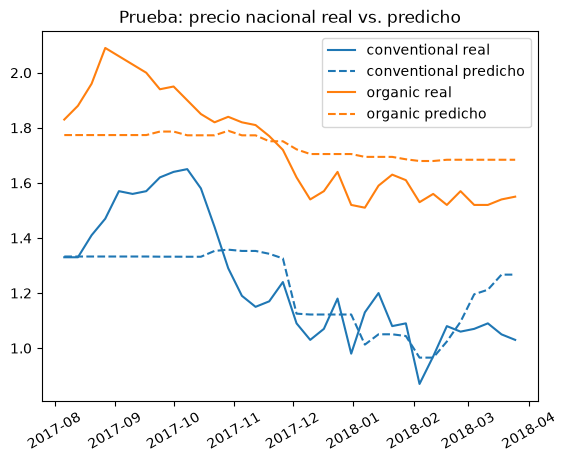

In [16]:
nacional = test.assign(prediccion=y_pred)
nacional = nacional[nacional.region == "TotalUS"]
for tipo, color in [("conventional", "tab:blue"), ("organic", "tab:orange")]:
    parte = nacional[nacional.tipo == tipo]
    plt.plot(parte.fecha, parte[OBJETIVO], color=color, label=f"{tipo} real")
    plt.plot(parte.fecha, parte.prediccion, color=color, linestyle="--", label=f"{tipo} predicho")
plt.legend()
plt.xticks(rotation=30)
plt.title("Prueba: precio nacional real vs. predicho")
plt.show()

El modelo mejora a la línea base, pero **no reproduce el pico de agosto a octubre de 2017**: predice una línea casi plana alrededor del último nivel conocido. Es esperable, porque un cambio de nivel de ese tipo no se puede anticipar solo con la región, el tipo y la fecha.

### Modelo para servir

Las métricas son las de la partición temporal. Para usar el modelo (por ejemplo desde la API), se reentrena con todas las semanas, para que conozca los precios más recientes. Esas métricas ya no se pueden medir con datos independientes.

In [17]:
final = candidatos()[ganador].fit(df[VARIABLES], df[OBJETIVO])
consulta = pd.DataFrame([{"region": "TotalUS", "tipo": "conventional", "fecha": pd.Timestamp("2018-04-01")}])
print("Precio estimado (convencional, todo EE. UU., 1 abril 2018): %.2f USD" % final.predict(consulta)[0])

Precio estimado (convencional, todo EE. UU., 1 abril 2018): 1.14 USD


---
# Conclusiones
---

## Resultados

Con la región, el tipo y la fecha se puede estimar el precio del aguacate con un error medio de aproximadamente 0.23 dólares, algo mejor que usar el promedio histórico de cada serie. Lo que sí se puede predecir es el nivel de cada región, la diferencia entre orgánico y convencional y una estacionalidad anual moderada.

Lo que no se puede predecir con estas variables es el nivel general de precios, que cambia por shocks de oferta como el de 2017. Para mejorar de forma importante haría falta información externa (producción, clima, aranceles) o el precio reciente del mercado.

Limitaciones: los datos terminan en marzo de 2018, así que para fechas posteriores el resultado es una estimación basada en la estacionalidad y en el último nivel conocido, y es poco confiable. Solo hay tres ciclos anuales completos. Las regiones agregadas se solapan con las ciudades. La prueba es una sola ventana de 34 semanas con un episodio extremo.

### Referencias

> Bergmeir, C., & Benítez, J. M. (2012). On the use of cross-validation for time series predictor evaluation. *Information Sciences*.
> Kiggins, J. (2018). *Avocado Prices* [Conjunto de datos del Hass Avocado Board]. Kaggle.
> Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice* (3.ª ed.). OTexts.